# spMosaic Tutorial Example 2: Integrating samples from MERFISH_FC Donor10, 11 and 12

The MERFISH_FC dataset contains 8 samples from 3 donors. In this tutorial, we demonstrate how to use spMosaic to integrate samples across multiple donors.

spMosaic can integrate samples regardless of whether they come from the same donor or different donors. The workflow is the same as in the single-donor setting. The main requirement is that each sample should have a unique label in the `sample_name` column. For more details on the basic input format, please refer to `Example1-Visium_DLPFC.ipynb`.

**Note.** This example is a faster end-to-end tutorial for running the full spMosaic pipeline. It should take only a few minutes to finish, compared with the Visium_DLPFC example in `Example1-Visium_DLPFC.ipynb`, which may take more than an hour depending on the computing environment.

The `.h5ad` file used in this tutorial can be downloaded from this [link](https://www.dropbox.com/scl/fo/c2fonb4sbeiu9ddrtlm87/ALQAjA_jman3udZRRjD32Ow?rlkey=acn3m5dwbj6ce6ipjex3fadbk&st=y6e8m7dm&dl=0).

In [1]:
import sys
import os
import scanpy as sc
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score

from spmosaic import gene_smooth, domain_detection, get_rscript_path

# set working directory
os.chdir("/rhome/sfu036/bigdata/spMosaic_example_data")
# input data for Donor1
Donor10to12_h5ad = sc.read_h5ad("MERFISH_FC/MERFISH_FC_Donor10-12.h5ad")

In [2]:
Donor10to12_h5ad.X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 33753126 stored elements and shape (90249, 374)>

In [3]:
Donor10to12_h5ad.obs.head()

,sample_name,row,col,domain_guess
barcode,,,,
wk24_Donor10_Slice0_710X-1665,wk24_Donor10_Slice0,-1665.169975,710.904446,olfactory region
wk24_Donor10_Slice0_617X-1693,wk24_Donor10_Slice0,-1693.237474,617.818448,olfactory region
wk24_Donor10_Slice0_661X-1512,wk24_Donor10_Slice0,-1512.475974,661.636447,olfactory region
wk24_Donor10_Slice0_700X-1700,wk24_Donor10_Slice0,-1700.213474,700.440446,olfactory region
wk24_Donor10_Slice0_718X-1541,wk24_Donor10_Slice0,-1541.127978,718.043946,olfactory region


Next, we visualize the **annotated** spatial domains for each sample using the spot coordinates. 

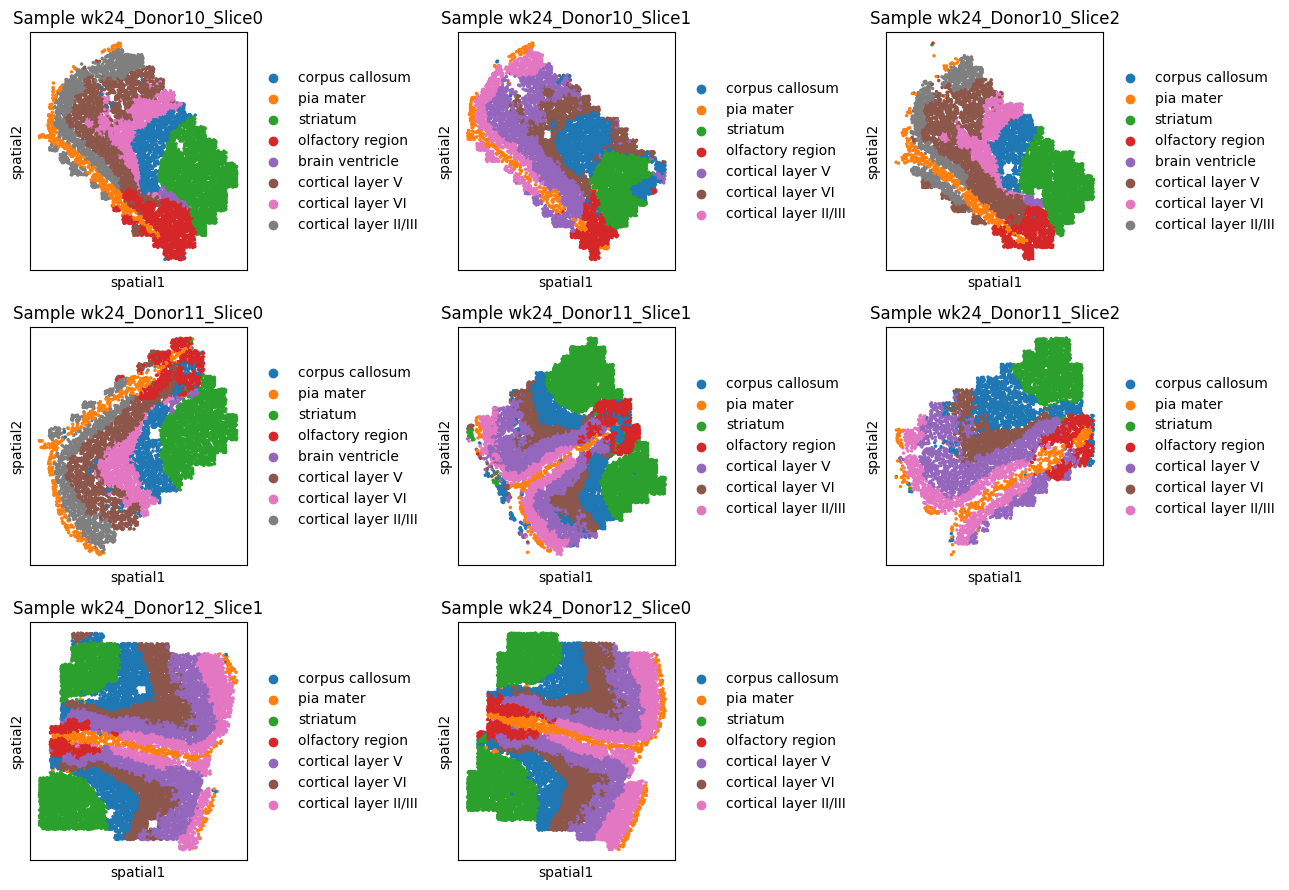

In [9]:
Donor10to12_h5ad.obsm["spatial"] = Donor10to12_h5ad.obs[["col", "row"]].to_numpy()

samples = Donor10to12_h5ad.obs["sample_name"].unique()

fig, axes = plt.subplots(3, 3, figsize=(13, 9))

for sample, ax in zip(samples, axes.flatten()):
    adata_sub = Donor10to12_h5ad[
        Donor10to12_h5ad.obs["sample_name"] == sample
    ].copy()

    sc.pl.embedding(
        adata_sub,
        basis="spatial",
        color="domain_guess",
        size=25,
        ax=ax,
        show=False,
        title=f"Sample {sample}"
    )

for ax in axes.flatten()[len(samples):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

### II. Stage 1: spatial smoothing

This stage uses the same workflow as in `Example1-Visium_DLPFC.ipynb`, so you can refer to that tutorial for detailed explanations of the input parameters and output files.

The main difference is that the MERFISH gene expression data are continuous rather than count-based. Therefore, when running the `gene_smooth` function, make sure to set: `data_type="continuous"`.

For most machines, this gene smoothing step should be relatively fast and usually takes only a few minutes to finish.

In [2]:
# Check the Python executable being used.
# This should point to the conda environment where spMosaic is installed.
print(sys.executable)

# Check the Rscript executable being used.
# This should point to the Rscript inside the same conda environment.
print(get_rscript_path())

gam_results = gene_smooth(
    h5ad_path="MERFISH_FC/MERFISH_FC_Donor10-12.h5ad",
    out_dir="MERFISH_FC/Donor10-12_mid",
    prefix="Donor10-12",
    data_type="continuous",
    ncores=16,
    k_num=150,
    blas_threads=1
)

/rhome/sfu036/bigdata/.conda/envs/spmosaic-env/bin/python
/rhome/sfu036/bigdata/.conda/envs/spmosaic-env/bin/Rscript
Step 1-1: Exporting .h5ad intermediate files for R GAM smoothing...
Loading AnnData from data/MERFISH_FC/MERFISH_FC_Donor10-12.h5ad...
Saving expression matrix...
Saving gene names...
Saving barcodes...
Saving observation metadata...
Export complete. Intermediate files saved to data/MERFISH_FC/Donor10-12_mid/Donor10-12_gam_input
Step 1-2: Running R GAM smoothing script...
Using Rscript: /rhome/sfu036/bigdata/.conda/envs/spmosaic-env/bin/Rscript
Running command:
/rhome/sfu036/bigdata/.conda/envs/spmosaic-env/bin/Rscript /bigdata/wlilab/sfu036/software/spMosaic/src/spmosaic/r/fit_gam.R data/MERFISH_FC/Donor10-12_mid Donor10-12 16 150 True continuous data/MERFISH_FC/Donor10-12_mid
[1] "BLAS/OpenMP thread settings seen by R:"
       OMP_NUM_THREADS   OPENBLAS_NUM_THREADS        MKL_NUM_THREADS 
                   "1"                    "1"                    "1" 
VECLIB_MAXI

### III. Stage 2: spatial domain detection

For this stage, we follow the same parameter setting guidelines as described in `Example1-Visium_DLPFC.ipynb`, so you can refer to that tutorial for detailed explanations of the input parameters and output files.

In this example, we set `n_clusters = 8`, which matches the annotated number of spatial domains in the MERFISH_FC dataset.

In [2]:
domain_outs_h5ad = domain_detection(
    h5ad_path = "MERFISH_FC/MERFISH_FC_Donor10-12.h5ad",
    input_dir = "MERFISH_FC/Donor10-12_mid",
    prefix = "Donor10-12",
    n_clusters = 8, # set to the annotated domain number
    clust_method = "mclust",
    SVG_selection_method = "common",
    lambda_b = 1e0,
    alpha = 1e-3,
    fix_seed= 888,
    if_cluster_refine = True,
    blas_threads=1
)

Device being used is: cuda
Step 2-1: Reading in GAM output for spatial domain detection...
Common_svgs number: 198
Union_svgs number: 366
Gene selection method used is: common
Step 2-2: Pretraning dual-encoder autoencoder ...
Epoch 10, Training Loss - Recon: 0.9964 | Class: 2.0834 | Total: 3.0798
Epoch 10, Testing Loss - Recon: 0.9962 | Class: 2.0839 | Total: 3.0801
Epoch 20, Training Loss - Recon: 0.9840 | Class: 2.0791 | Total: 3.0631
Epoch 20, Testing Loss - Recon: 0.9823 | Class: 2.0800 | Total: 3.0623
Epoch 30, Training Loss - Recon: 0.9538 | Class: 2.0761 | Total: 3.0299
Epoch 30, Testing Loss - Recon: 0.9487 | Class: 2.0770 | Total: 3.0257
Epoch 40, Training Loss - Recon: 0.8894 | Class: 2.0730 | Total: 2.9625
Epoch 40, Testing Loss - Recon: 0.8786 | Class: 2.0738 | Total: 2.9524
Epoch 50, Training Loss - Recon: 0.7922 | Class: 2.0695 | Total: 2.8617
Epoch 50, Testing Loss - Recon: 0.7790 | Class: 2.0702 | Total: 2.8493
Epoch 60, Training Loss - Recon: 0.7268 | Class: 2.0649 | T

Next, we evaluate the spMosaic results by comparing the inferred spatial domains with the annotated domain labels. We first calculate the Adjusted Rand Index (ARI) between the annotation (`domain_guess`) and the inferred spatial domains. Here, we use `spatial_cluster_refined`, which contains the final spatial domain labels after the optional KNN-based refinement step.

In [5]:
adjusted_rand_score(domain_outs_h5ad.obs["domain_guess"], domain_outs_h5ad.obs["spatial_cluster_refined"])

0.668687377819863

Next, we visualize the **inferred** spatial domains for each sample using the spot coordinates. 

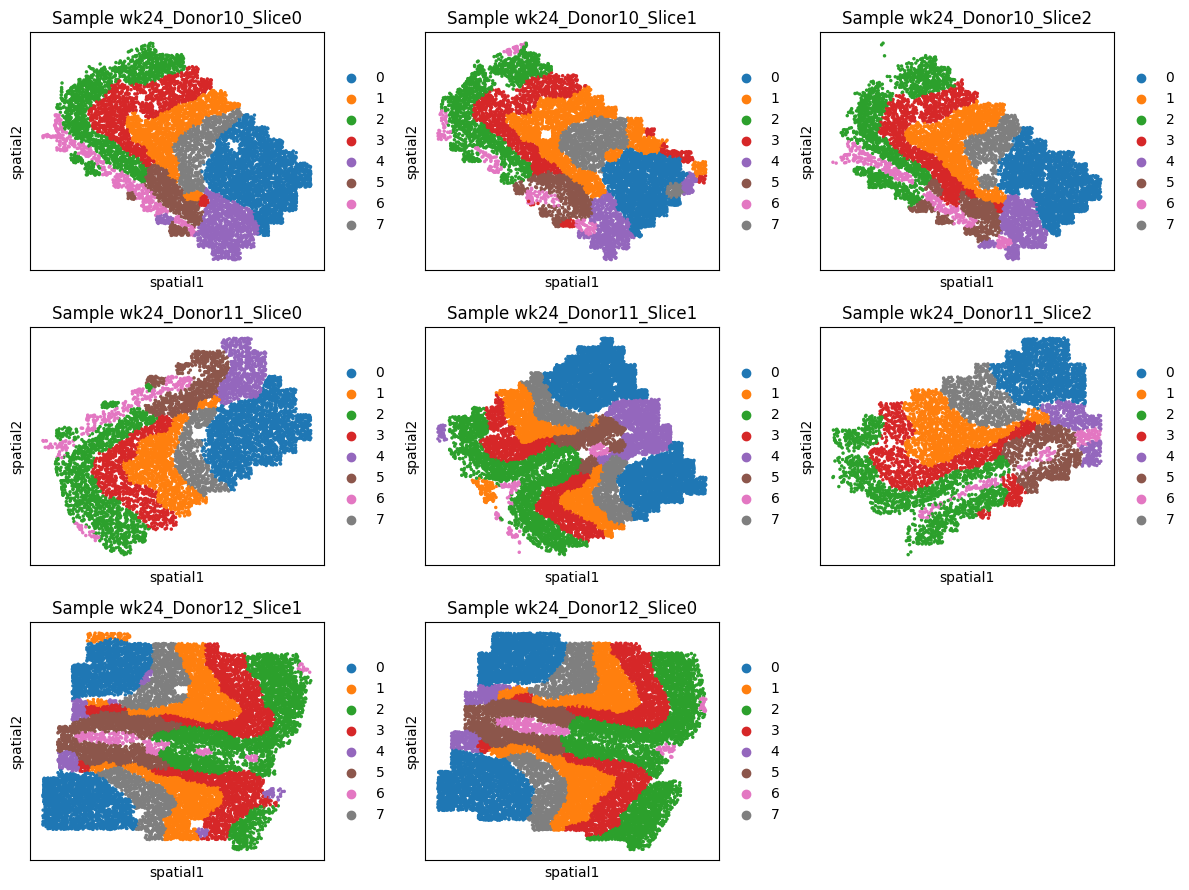

In [6]:
domain_outs_h5ad.obsm["spatial"] = domain_outs_h5ad.obs[["col", "row"]].to_numpy()

samples = domain_outs_h5ad.obs["sample_name"].unique()

fig, axes = plt.subplots(3, 3, figsize=(12, 9))

for sample, ax in zip(samples, axes.flatten()):
    adata_sub = domain_outs_h5ad[
        domain_outs_h5ad.obs["sample_name"] == sample
    ].copy()

    sc.pl.embedding(
        adata_sub,
        basis="spatial",
        color="spatial_cluster_refined",
        size=25,
        ax=ax,
        show=False,
        title=f"Sample {sample}"
    )

for ax in axes.flatten()[len(samples):]:
    ax.axis("off")

plt.tight_layout()
plt.show()